#  Anomaly Detection & Demand Forecasting

### Objective
This notebook focuses on identifying unusual customer transactions using Isolation Forest and forecasting future demand using Time Series Analysis.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [12]:
df = pd.read_csv("../../member 1/cleaned_data/cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [13]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (779425, 9)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalAmount'],
      dtype='object')

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalAmount    0
dtype: int64


In [14]:
# Convert InvoiceDate into datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Select numerical columns required for anomaly detection

anomaly_data = df[["Quantity", "Price", "TotalAmount"]]

anomaly_data.head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [15]:
model = IsolationForest(
    contamination=0.01,
    random_state=42
)

model.fit(anomaly_data)

print("Isolation Forest Model Trained Successfully!")

Isolation Forest Model Trained Successfully!


In [16]:
df["Anomaly"] = model.predict(anomaly_data)

df["Anomaly"].value_counts()

Anomaly
 1    771674
-1      7751
Name: count, dtype: int64

In [17]:
anomalies = df[df["Anomaly"] == -1]

print("Total Anomalies:", len(anomalies))

anomalies.head()

Total Anomalies: 7751


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Anomaly
67,489438,85132A,CHARLIE + LOLA BISCUITS TINS,60,2009-12-01 09:24:00,6.38,18102,United Kingdom,382.80,-1
68,489438,85132C,CHARLIE AND LOLA FIGURES TINS,60,2009-12-01 09:24:00,6.40,18102,United Kingdom,384.00,-1
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636,USA,141.00,-1
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362,Belgium,130.00,-1
195,489460,84598,BOYS ALPHABET IRON ON PATCHES,576,2009-12-01 10:46:00,0.21,16167,United Kingdom,120.96,-1


/Users/icg/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


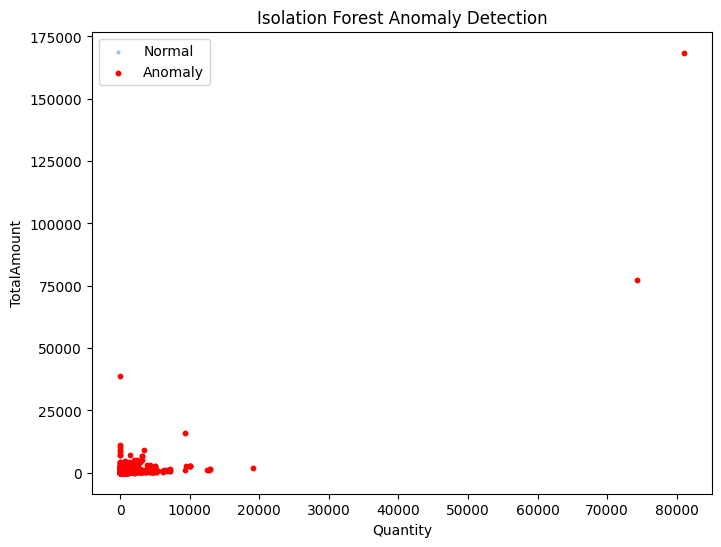

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Quantity"],
    df["TotalAmount"],
    s=5,
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    anomalies["Quantity"],
    anomalies["TotalAmount"],
    color="red",
    s=10,
    label="Anomaly"
)

plt.xlabel("Quantity")
plt.ylabel("TotalAmount")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()

plt.show()

In [19]:
print("Total Transactions :", len(df))
print("Normal Transactions :", (df["Anomaly"] == 1).sum())
print("Anomalous Transactions :", (df["Anomaly"] == -1).sum())

print("\nPercentage of Anomalies: {:.2f}%".format(
    ((df["Anomaly"] == -1).sum() / len(df)) * 100
))

Total Transactions : 779425
Normal Transactions : 771674
Anomalous Transactions : 7751

Percentage of Anomalies: 0.99%
